In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

In [2]:
crime_df = pd.read_csv('data/crime-housing-austin-2015.csv')
print(crime_df.shape)
print(f"Player Data Columns: \n{crime_df.columns}\n")
'''
We need to tread very carefully here
The project description gives the required methods: Pearson correlations, scatterplots, averages, standard deviations, and a t-test
Ideas:
- 
'''


(38573, 43)
Player Data Columns: 
Index(['Key', 'Council_District', 'Highest_Offense_Desc',
       'Highest_NIBRS_UCR_Offense_Description', 'Report_Date', 'Location',
       'Clearance_Status', 'Clearance_Date', 'District', 'Zip_Code_Crime',
       'Census_Tract', 'X_Coordinate', 'Y_Coordinate', 'Zip_Code_Housing',
       'Populationbelowpovertylevel', 'Medianhouseholdincome',
       'Non-WhiteNon-HispanicorLatino', 'HispanicorLatinoofanyrace',
       'Populationwithdisability', 'Unemployment',
       'Largehouseholds(5+members)',
       'Homesaffordabletopeopleearninglessthan$50000',
       'Rentalsaffordabletopeopleearninglessthan$25000',
       'Rent-restrictedunits', 'HousingChoiceVoucherholders', 'Medianrent',
       'Medianhomevalue', 'Percentageofrentalunitsinpoorcondition',
       'Percentchangeinnumberofhousingunits2000-2012',
       'Ownerunitsaffordabletoaverageretail/serviceworker',
       'Rentalunitsaffordabletoaverageretail/serviceworker',
       'Rentalunitsaffordableto

'\nWe need to tread very carefully here\nThe project description gives the required methods: Pearson correlations, scatterplots, averages, standard deviations, and a t-test\nIdeas:\n- \n'

# Crimes on weekends

In [3]:
crime_df = crime_df[crime_df.columns].copy()
crime_df['Report_Date'] = pd.to_datetime(crime_df["Report_Date"], format="%d-%b-%y")
#print(crime_type.head())
weekends_df = crime_df.dropna().copy()
weekends_df["Report_Date"] = pd.to_datetime(weekends_df["Report_Date"], format="%d-%b-%y")

#Check each entry; mark if the entry occurs on a weekend
weekends_df["Is_Weekend"] = weekends_df['Report_Date'].dt.day_of_week > 4
print(weekends_df[weekends_df["Is_Weekend"] == True])


               Key  Council_District    Highest_Offense_Desc  \
198      201530504               3.0  BURGLARY NON RESIDENCE   
199      201530459               4.0  BURGLARY NON RESIDENCE   
200      201521668               3.0   BURGLARY OF RESIDENCE   
201      201530966               2.0   BURGLARY OF RESIDENCE   
202      201531405               7.0   BURGLARY OF RESIDENCE   
...            ...               ...                     ...   
38124  20155056372               3.0        THEFT OF BICYCLE   
38125  20155056364               3.0                   THEFT   
38126  20155056348               7.0                   THEFT   
38127  20155056391               5.0                   THEFT   
38128  20155056387               7.0                   THEFT   

      Highest_NIBRS_UCR_Offense_Description Report_Date  \
198                                Burglary  2015-01-03   
199                                Burglary  2015-01-03   
200                                Burglary  2015-01-0

# Is there a difference in popular crime types on weekends vs weekdays? 

In [4]:
# Split set based on whether or not crime occurred on a weekend
on_weekends = weekends_df[weekends_df["Is_Weekend"] == True]
not_weekends = weekends_df[weekends_df["Is_Weekend"] == False]

weekend_ct = weekends_df.groupby('Report_Date').count().reset_index()
print(weekend_ct.head())

#print(len(on_weekends[on_weekends.Report_Date == '2015-01-03']))
# print(f"Crime occurring on weekends out of total: {on_weekends}/{tot}")
# print(f"%: {on_weekends/tot}")
# print(f"Crime occurring on weekdays out of total: {not_weekends}/{tot}")
# print(f"%: {not_weekends/tot}")

  Report_Date  Key  Council_District  Highest_Offense_Desc  \
0  2015-01-01   77                77                    77   
1  2015-01-02  103               103                   103   
2  2015-01-03   86                86                    86   
3  2015-01-04   71                71                    71   
4  2015-01-05  120               120                   120   

   Highest_NIBRS_UCR_Offense_Description  Location  Clearance_Status  \
0                                     77        77                77   
1                                    103       103               103   
2                                     86        86                86   
3                                     71        71                71   
4                                    120       120               120   

   Clearance_Date  District  Zip_Code_Crime  ...  \
0              77        77              77  ...   
1             103       103             103  ...   
2              86        86           

<Axes: xlabel='Highest_NIBRS_UCR_Offense_Description', ylabel='count'>

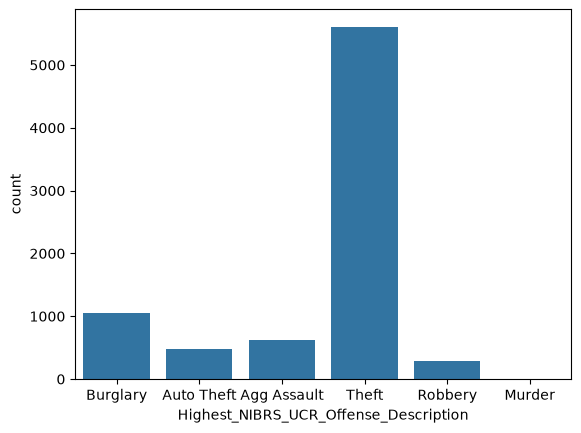

In [5]:
sns.countplot(x="Highest_NIBRS_UCR_Offense_Description", data=on_weekends)

<Axes: xlabel='Highest_NIBRS_UCR_Offense_Description', ylabel='count'>

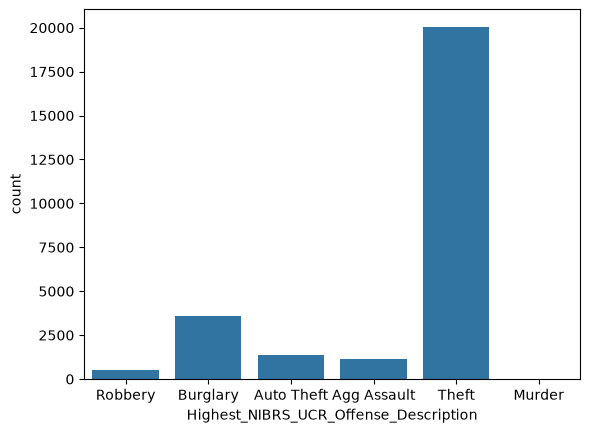

In [6]:
sns.countplot(x="Highest_NIBRS_UCR_Offense_Description", data=not_weekends)



In [7]:

#[offense, total]

# Weather stuff
---------------

In [16]:
# Read weather csv
weather_df = pd.read_csv('data/austin_weather.csv')
# parse date
weather_df['Report_Date'] = pd.to_datetime(weather_df["Date"], format="%Y-%m-%d")
wetcrime_df = crime_df.merge(weather_df, on='Report_Date').reset_index()
#print(wetcrime_df.head())
#rain_df = wetcrime_df[wetcrime_df.Events.str.contains('Rain')]
#no_rain_df = wetcrime_df[~wetcrime_df.Events.str.contains('Rain')]
wetcrime_df['PrecipitationSumInches'] = wetcrime_df['PrecipitationSumInches'].str.replace("T", '0.0').astype(float)
print(wetcrime_df['PrecipitationSumInches'])


0        0.63
1        0.63
2        0.63
3        0.63
4        0.63
         ... 
38568    0.00
38569    0.00
38570    0.00
38571    0.00
38572    0.00
Name: PrecipitationSumInches, Length: 38573, dtype: float64


-0.11439943264197393
0.0306928359272779


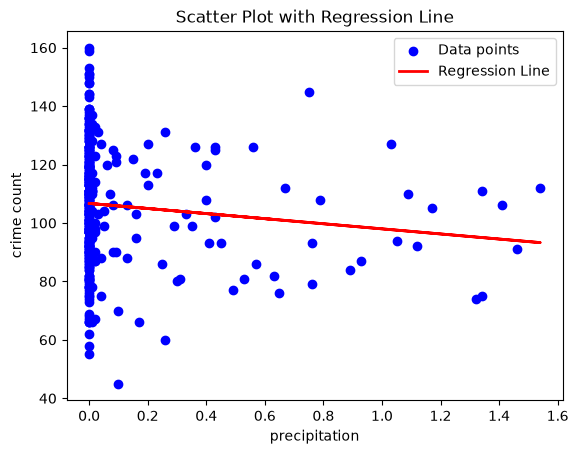

In [43]:
precip_count = wetcrime_df.copy()
precip_count = precip_count.groupby('Report_Date')['Key'].nunique().reset_index().rename(columns={'Key' : 'Crime Count'})
precip_count = precip_count.merge(weather_df, on='Report_Date')
precip_count = precip_count[['Report_Date', 'Crime Count', 'PrecipitationSumInches']]

precip_count['PrecipitationSumInches'] = precip_count['PrecipitationSumInches'].str.replace("T", '0.0').astype(float)

no_precip_count = wetcrime_df[wetcrime_df.PrecipitationSumInches == 0].copy()
no_precip_count = no_precip_count.groupby('Report_Date')['Key'].nunique().reset_index().rename(columns={'Key' : 'Crime Count'})
no_precip_count = no_precip_count.merge(weather_df, on='Report_Date')
no_precip_count = no_precip_count[['Report_Date', 'Crime Count', 'PrecipitationSumInches']].copy()
no_precip_count['PrecipitationSumInches'] = no_precip_count['PrecipitationSumInches'].str.replace("T", '0.0').astype(float)
no_precip_count = no_precip_count[['Crime Count', 'PrecipitationSumInches']]

avg = precip_count['PrecipitationSumInches'].mean()

sd = precip_count['PrecipitationSumInches'].std()

precip_count = precip_count[(precip_count.PrecipitationSumInches < avg+(3*sd))&(precip_count.PrecipitationSumInches > avg-(3*sd))]

corr, p = stats.pearsonr(precip_count['PrecipitationSumInches'], precip_count['Crime Count'])
print(corr)
print(p)

slope, intercept = np.polyfit(precip_count['PrecipitationSumInches'], precip_count['Crime Count'], 1)
# 3. Create the scatter plot
plt.scatter(precip_count['PrecipitationSumInches'], precip_count['Crime Count'], color='blue', label='Data points')

# 4. Plot the regression line (y = mx + b)
plt.plot(precip_count['PrecipitationSumInches'], slope * precip_count['PrecipitationSumInches'] + intercept, color='red', linewidth=2, label='Regression Line')

# 5. Add details and show
plt.xlabel('precipitation')
plt.ylabel('crime count')
plt.title('Scatter Plot with Regression Line')
plt.legend()
plt.show()

### Is there a correlation between crime and precipitation?